In [18]:
# Import libraries
%reload_ext autoreload
%autoreload 2

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from IPython.display import display, HTML, Latex, Image, Video
from IPython.display import Markdown as md
from IPython.core.magic import register_cell_magic
from tabulate import tabulate
from sklearn.linear_model import LinearRegression
import mercury as mr
import datetime

@register_cell_magic
def markdown(line, cell):
    return md(cell.format(**globals()))

last_friday = datetime.date.today() - pd.offsets.Week(weekday=4)

pcourse_name     = "Course Name"
dcourse_name        = "PHYS 2125 (15921)"
pcourse_semester = "Semester"
dcourse_semester    = "Spring 2025"
pstudent_name    = "What is Your Name?"
dstudent_name       = "Sir Lancelot of Camelot"
plab_date        = "Lab Date"
dlab_date           = last_friday.strftime("%Y-%m-%d")
plab_number      = "Lab Number"
dlab_number         = "12"
plab_name        = "Lab Name"
dlab_name           = "Projectile 1 (Symmetric Parabola)"
plab_objective   = "Lab Objective"
dlab_objective      = "To determine the speed of the projectile in two different methods and compare the values."
pdata1_filename   = "Data filename"
ddata1_filename      = 'lab' + dlab_number + '-a.csv'
pdata1_index      = "Index Column"
ddata1_index         = 0
columnsA         = ["$H (m)$", "$R (m)$", "$v_0 (s)$"]
pdata2_filename   = "Data filename"
ddata2_filename      = 'lab' + dlab_number + '-b.csv'
pdata2_index      = "Index Column"
ddata2_index         = 0
columnsB         = ["$\\theta (\\deg)$", "$H (m)$", "$R (m)$", "$cos \\theta (m)$", "$v_0 (s)$"]
#pgraph_x_label   = "Label for graph x-axis"
#dgraph_x_label      = '$sin2\\theta (m)$'
#pgraph_y_label   = "Label for graph y-axis"
#dgraph_y_label      = '$R (m)$'
#pgraph_label     = "$sin2\\theta (m)$ vs "
#dgraph_label        = dgraph_y_label + " vs " + dgraph_x_label
pquestion_1      = "What is your quest?"
dquestion_1         = "To seek the holy grail."
pquestion_2      = "What is your favorite color?"
dquestion_2         = "Blue."
pquestion_3      = "What is the capital of Assyria?"
dquestion_3         = "I don't know that!"

# TODO: Add a field to select columns to compute average for
pcalc_average    = "Compute average for fields"
# TODO: Add a field to compute Std Dev for
pcalc_deviation  = "Compute standard deviation for fields"

# TODO: Add a field(s) for attaching an image to the Theory (or other) sections(s).

# TODO: Add a field to select columns to compute average for
calc_average    = 1
# TODO: Add a field to compute Std Dev for
calc_deviation  = 1

In [21]:
%autoreload 2

app             = mr.App(title="Lab " + dlab_number + " - " + dlab_name, description="Lab report for " + dcourse_name + " " + dcourse_semester + " Lab " + dlab_number + ".")
course_name     = mr.Text(label=pcourse_name,     value=dcourse_name,     rows=1)
course_semester = mr.Text(label=pcourse_semester, value=dcourse_semester, rows=1)
student_name    = mr.Text(label=pstudent_name,    value=dstudent_name,    rows=1)
lab_date        = mr.Text(label=plab_date,        value=dlab_date,        rows=1)
lab_number      = mr.Text(label=plab_number,      value=dlab_number,      rows=1)
lab_name        = mr.Text(label=plab_name,        value=dlab_name,        rows=1)
lab_objective   = mr.Text(label=plab_name,        value=dlab_objective,   rows=1)
data1_filename   = mr.Text(label=pdata1_filename, value=ddata1_filename,   rows=1)
data1_index      = mr.Numeric(label=pdata1_index, value=ddata1_index,      step=1)
data2_filename   = mr.Text(label=pdata2_filename, value=ddata2_filename,   rows=1)
data2_index      = mr.Numeric(label=pdata2_index, value=ddata2_index,      step=1)
#data_columns    = mr.Text(label=pdata_columns,    value=ddata_columns,    rows=1)
#graph_x_label   = mr.Text(label=pgraph_x_label,   value=dgraph_x_label,   rows=1)
#graph_y_label   = mr.Text(label=pgraph_y_label,   value=dgraph_y_label,   rows=1)
#graph_label     = mr.Text(label=pgraph_label,     value=dgraph_label,     rows=1)
question_1      = mr.Text(label=pquestion_1,      value=dquestion_1,      rows=1)
question_2      = mr.Text(label=pquestion_2,      value=dquestion_2,      rows=1)
question_3      = mr.Text(label=pquestion_3,      value=dquestion_3,      rows=1)

discuss         = mr.Text(value="Discussion",             label="Discuss", rows=5)
file1           = mr.File(label="Data file 1 upload",       max_file_size="10MB")
file2           = mr.File(label="Data file 2 upload",       max_file_size="10MB")

#remove_rows     = mr.Numeric(label="Rows to drop from the data", value=0,  step=1)

if file1.filepath is not None:
    dfA = pd.read_csv(file1.filepath, names=columnsA, header=0)
else:
    dfA = pd.read_csv(ddata1_filename, names=columnsA, header=0)

if file2.filepath is not None:
    dfB = pd.read_csv(file2.filepath, names=columnsB, header=0)
else:
    dfB = pd.read_csv(ddata2_filename, names=columnsB, header=0)

# Remove the last row(s) with the empty index
# df.drop(df.tail(remove_rows.value).index, inplace=True)

# Mean and StdDev across the board
meanA = dfA.mean()
deviationA = dfA.std(ddof=0)
v_0_a = meanA[columnsA[2]];
v_0_a_dev = deviationA[columnsA[2]];

dfA.loc['Average'] = {
    columnsA[1]: np.nan,
    columnsA[2]: v_0_a
};
dfA.loc['StdDev'] = {
    columnsA[1]: np.nan,
    columnsA[2]: v_0_a_dev
};

meanB = dfB.mean()
deviationB = dfB.std(ddof=0)
v_0_b = meanB[columnsB[4]];
v_0_b_dev = deviationB[columnsB[4]];

dfB.loc['Average'] = {
    columnsB[1]: np.nan,
    columnsB[2]: np.nan,
    columnsB[3]: np.nan,
    columnsB[4]: v_0_a
};
dfB.loc['StdDev'] = {
    columnsB[1]: np.nan,
    columnsB[2]: np.nan,
    columnsB[3]: np.nan,
    columnsB[4]: v_0_a_dev
};

v_0_diff = abs( v_0_a - v_0_b ) / ( ( v_0_a + v_0_b ) / 2 )

#dfA = df.set_index(columnsA[int(data1_index.value)])
#dfB = df.set_index(columnsB[int(data2_index.value)])

# Formatting
#df[columns[2]] = df.apply(lambda row: f"{row[columns[1]]:.4f}", axis=1)
#df[columns[2]] = df.apply(lambda row: f"{row[columns[2]]:.4f}", axis=1)
#df[columns[3]] = df.apply(lambda row: f"{row[columns[3]]:.4f}", axis=1)
#df[columns[4]] = df.apply(lambda row: f"{row[columns[4]]:.4f}", axis=1)
#df[columns[5]] = df.apply(lambda row: f"{row[columns[5]]:.4f}", axis=1)

# Save this for the table
df_table = df.fillna('');

# Make some strings
v_0_a_str = str("%.4f" % round(v_0_a, 4))
v_0_a_dev_str = str("%.4f" % round(v_0_a_dev, 4))
v_0_b_str = str("%.4f" % round(v_0_b, 4))
v_0_b_dev_str = str("%.4f" % round(v_0_b_dev, 4))
v_0_diff_str = str("%.4f" % round(v_0_diff, 4))

mercury.App

mercury.Text

mercury.Text

mercury.Text

mercury.Text

...

mercury.Text

mercury.Text

mercury.Text

mercury.File

mercury.File

In [22]:
%%markdown

# Lab {lab_number.value}: {lab_name.value}
Name: **{student_name.value}** \
Class: **{course_name.value}** \
Date: **{lab_date.value}**

<p style="page-break-after:always;"></p>

## Objective

{lab_objective.value}


# Lab 12: Projectile 1 (Symmetric Parabola)
Name: **Sir Lancelot of Camelot** \
Class: **PHYS 2125 (15921)** \
Date: **2025-04-11**

<p style="page-break-after:always;"></p>

## Objective

To determine the speed of the projectile in two different methods and compare the values.


## Equipment

This experiment was simulated using http://phet.colorado.edu/sims/html/projectile-motion/latest/projectile-motion_all.html.

<p style="page-break-after:always;"></p>

## Theory

### Part A - Horizontal Projectile

![Graph of height vs time of object thrown from a height greater than 0.](https://docs.google.com/drawings/d/e/2PACX-1vR9hTN4O_aUCKUPWjlleBAhmD46OXl2LJCz5z0e-ZtRa7e63OK5tAKcu6LCFNLCduNDMDuP7wmgjhwQ/pub?w=327 "Graph of height vs time of object thrown from a height greater than 0.")

$\uparrow v_{0y} = 0;\; a = -g;\; \Delta y = - H;\; t = t$

$\rightarrow v_{0x} = v_0;\; a = 0;\; \Delta x = R;\; t = t$

$\rightarrow \Delta x = v_{0x} t + \dfrac{1}{2} a t^2$

$R = v_{0} t + 0$

$\uparrow \Delta y = v_{0y} t + \dfrac{1}{2} a t^2$

$-H = 0 + \dfrac{1}{2} (-g) t^2$

$t = \sqrt{\dfrac{2 H}{g}}$

$R = v_0 \sqrt{\dfrac{2H}{g}}$

$v_0 = \dfrac{R}{\sqrt{\dfrac{2H}{g}}}$

### Part B - Projecting From a Height

![Graph of height vs time of object thrown from a height 0.](https://docs.google.com/drawings/d/e/2PACX-1vT0DK-vBRcIvk4xQrTVYytFyBY1kfX3woWLR7xfOlGuckIlPgHEmEnEXu5cj-ePxsxeumvrnJz_cKDo/pub?w=481 "Graph of height vs time of object thrown from a height 0.")








In the horizontal $x$ direction

$v_{0x} = v_0cos \theta$; $a = 0$, $t = T$, $\Delta x = R$.

And in the vertical $y$ direction

$v_{0y} = v_0sin \theta$; $a = -g$, $t = T$, $\Delta y = 0$, 

Solving for T,

$\Delta y = v_{0y}t + \frac{1}{2}Rt^2$.

$0 = v_0sin\theta T + \frac{1}{2}(-g)T^2$

$T[v_0sin \theta] - \frac{1}{2}gT] = 0$, so

$T=0$ or $v_0sin\theta = \frac{1}{2}gT$

$T = \dfrac{2v_0sin \theta}{g}$

And solving for R,

$\Delta x = v_{0x}t+\frac{1}{2}at^2$

$R = (v_0cos \theta)T + 0$

$R = (v_0 cos \theta) \cdot \dfrac{2v_0sin \theta}{g}$

$R = \frac{v_0}{g}(2sin \theta cos \theta)$

$R = \frac{v_0}{g}(sin 2\theta)$



Where 

$R$ is the horizontal range of the projectile,

$H$ is the height of the projectile

$v_0$ is the initial velocity

$\theta$ is the angle of projection.

$a$ is acceleration,

$t$ is time,

$T$ is the total time between projection and collission.

<p style="page-break-after:always;"></p>

## Procedure

The following procedure was followed.

### Initial Setup

1. Selected the "lab" option.
1. Left all settings at their default value.


### Trial (completed twice for each frequency)

1. The angle of launch was adjusted per the trial.
1. The target was moved to measure R.
2. Once a good measurement of R was gathered it was recorded.

<p style="page-break-after:always;"></p>

## Data

In [4]:

%autoreload 2
# Print the data table
mr.Table(data=df_table, width="25px")
#HTML(df_table.to_html(notebook=True,col_space=10))

## Calculations

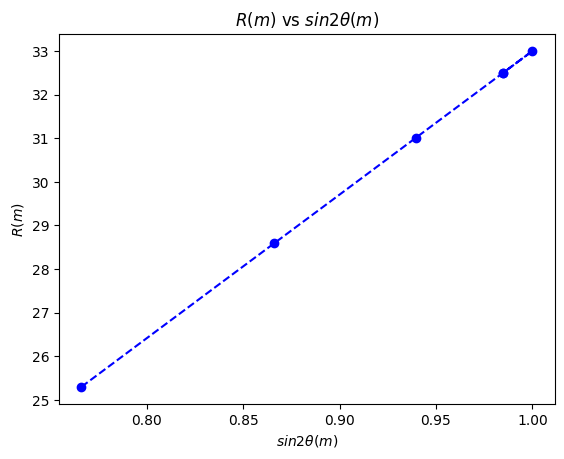

In [5]:
# Plot the measurements
plt.scatter(df_graph[columns[3]], df_graph[columns[1]], color="blue", marker="o");

# Plot the trendline
fit = np.polyval(trend, df_graph[columns[3]])
plt.plot(df_graph[columns[3]], fit, color="blue", linestyle="--")

# Add labels w LaTeX support
plt.xlabel(graph_x_label.value);
plt.ylabel(graph_y_label.value);
plt.title(graph_label.value);
plt.rcParams['text.usetex'] = True;
plt.rcParams['font.family'] = 'serif';

# Show the graph
plt.show();

In [6]:
%%markdown

Using the least squares method a trend line is fit to the data with *slope* {trend_slope_str} and *$y$-intercept* {trend_intercept_str}, resulting in the equation $ y = {trend_slope_str} x + {trend_intercept_str} $.

## Results

The average value of $v_0$ was calculated as ${v_t_str}\; \pm\; {v_t_dev_str}$.

Using the least squares method $v_0$ was calculated as ${v_g_str}$.

These two values differ by ${v_diff_str}$%.

## Questions

{pquestion_1}

{question_1.value}

{pquestion_2}

{question_2.value}

## Discussion

{discuss.value}


Using the least squares method a trend line is fit to the data with *slope* 32.8934 and *$y$-intercept* 0.1042, resulting in the equation $ y = 32.8934 x + 0.1042 $.

## Results

The average value of $v_0$ was calculated as $4.2420\; \pm\; 0.0004$.

Using the least squares method $v_0$ was calculated as $5.7353$.

These two values differ by $0.2993$%.

## Questions

A child throws a ball from 4.0 m height, at a velocity of 29.4 m/s at an initial angle of 60.0° with respect to the vertical. What is the Range of the during its trajectory from ground?

To seek the holy grail.

A cannon barrel is elevated 35º above the horizontal. It fires a ball with a speed of 300 m/s. What is the range of the projectile and the height does the ball reach?

Blue.

## Discussion

Discussion
